In [7]:
# Complete Statistical Testing Code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, shapiro, mannwhitneyu, kruskal, pearsonr, spearmanr, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset
df = pd.read_csv(r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart_Cleaned.csv')
df['date'] = pd.to_datetime(df['date'])  # Convert date back to datetime if needed
df['revenue'] = df['unit_price'] * df['quantity']

print("=" * 60)
print("📊 STATISTICAL HYPOTHESIS TESTING")
print("=" * 60)
print(f"✅ Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"💰 Total Revenue: ${df['revenue'].sum():,.2f}")
print("=" * 60)

📊 STATISTICAL HYPOTHESIS TESTING
✅ Loaded dataset: 10,000 rows, 18 columns
💰 Total Revenue: $1,155,753.96


NORMALITY TESTS

In [2]:
print("\n" + "=" * 70)
print("📊 1. NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 70)

numerical_cols = ['unit_price', 'quantity', 'rating', 'profit_margin', 'revenue']

for col in numerical_cols:
    # Sample 5000 if data is larger (Shapiro works best with <5000)
    sample_data = df[col].sample(min(5000, len(df)), random_state=42)
    stat, p_value = shapiro(sample_data)
    
    print(f"\n📊 {col.upper()}:")
    print(f"  Shapiro-Wilk Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  ✅ Normal (p > 0.05)")
    else:
        print(f"  ❌ Not Normal (p < 0.05)")
        print(f"  💡 Use non-parametric tests for this variable")


📊 1. NORMALITY TESTS (Shapiro-Wilk)

📊 UNIT_PRICE:
  Shapiro-Wilk Statistic: 0.9658
  P-Value: 0.0000
  ❌ Not Normal (p < 0.05)
  💡 Use non-parametric tests for this variable

📊 QUANTITY:
  Shapiro-Wilk Statistic: 0.8009
  P-Value: 0.0000
  ❌ Not Normal (p < 0.05)
  💡 Use non-parametric tests for this variable

📊 RATING:
  Shapiro-Wilk Statistic: 0.9507
  P-Value: 0.0000
  ❌ Not Normal (p < 0.05)
  💡 Use non-parametric tests for this variable

📊 PROFIT_MARGIN:
  Shapiro-Wilk Statistic: 0.7766
  P-Value: 0.0000
  ❌ Not Normal (p < 0.05)
  💡 Use non-parametric tests for this variable

📊 REVENUE:
  Shapiro-Wilk Statistic: 0.8129
  P-Value: 0.0000
  ❌ Not Normal (p < 0.05)
  💡 Use non-parametric tests for this variable


MANN-WHITNEY U TEST 

Creating tge column is_holyday for MAANN-WHITNEY U TEST

In [3]:
print("\n" + "=" * 70)
print("📊 1. MANN-WHITNEY U TEST (2 Independent Groups)")
print("=" * 70)

# 1.1 Payment Method: Cash vs Ewallet (Revenue)
cash_revenue = df[df['payment_method'] == 'Cash']['revenue']
ewallet_revenue = df[df['payment_method'] == 'Ewallet']['revenue']
credit_revenue = df[df['payment_method'] == 'Credit card']['revenue']

if len(cash_revenue) > 0 and len(ewallet_revenue) > 0:
    stat, p_value = mannwhitneyu(cash_revenue, ewallet_revenue, alternative='two-sided')
    print(f"\n💳 CASH vs EWALLET (Revenue):")
    print(f"  Cash Median: ${cash_revenue.median():.2f}")
    print(f"  Ewallet Median: ${ewallet_revenue.median():.2f}")
    print(f"  U-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 1.2 Payment Method: Cash vs Credit Card (Revenue)
if len(cash_revenue) > 0 and len(credit_revenue) > 0:
    stat, p_value = mannwhitneyu(cash_revenue, credit_revenue, alternative='two-sided')
    print(f"\n💳 CASH vs CREDIT CARD (Revenue):")
    print(f"  Cash Median: ${cash_revenue.median():.2f}")
    print(f"  Credit Card Median: ${credit_revenue.median():.2f}")
    print(f"  U-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 1.3 Ewallet vs Credit Card (Revenue)
if len(ewallet_revenue) > 0 and len(credit_revenue) > 0:
    stat, p_value = mannwhitneyu(ewallet_revenue, credit_revenue, alternative='two-sided')
    print(f"\n💳 EWALLET vs CREDIT CARD (Revenue):")
    print(f"  Ewallet Median: ${ewallet_revenue.median():.2f}")
    print(f"  Credit Card Median: ${credit_revenue.median():.2f}")
    print(f"  U-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 1.4 Top 2 Categories Rating Comparison
top_categories = df['category'].value_counts().head(2).index
if len(top_categories) == 2:
    cat1_rating = df[df['category'] == top_categories[0]]['rating']
    cat2_rating = df[df['category'] == top_categories[1]]['rating']
    stat, p_value = mannwhitneyu(cat1_rating, cat2_rating, alternative='two-sided')
    print(f"\n⭐ RATING: {top_categories[0]} vs {top_categories[1]}:")
    print(f"  {top_categories[0]} Median Rating: {cat1_rating.median():.2f}")
    print(f"  {top_categories[1]} Median Rating: {cat2_rating.median():.2f}")
    print(f"  U-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 1.5 Weekend vs Weekday Revenue
df['is_weekend'] = df['weekday'].isin([6, 7]).astype(int)  # Saturday=6, Sunday=7
weekend_revenue = df[df['is_weekend'] == 1]['revenue']
weekday_revenue = df[df['is_weekend'] == 0]['revenue']

if len(weekend_revenue) > 0 and len(weekday_revenue) > 0:
    stat, p_value = mannwhitneyu(weekend_revenue, weekday_revenue, alternative='two-sided')
    print(f"\n📅 WEEKEND vs WEEKDAY (Revenue):")
    print(f"  Weekend Median: ${weekend_revenue.median():.2f}")
    print(f"  Weekday Median: ${weekday_revenue.median():.2f}")
    print(f"  U-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")


📊 1. MANN-WHITNEY U TEST (2 Independent Groups)

💳 CASH vs EWALLET (Revenue):
  Cash Median: $100.00
  Ewallet Median: $87.00
  U-Statistic: 3872392.5000
  P-Value: 0.0000
  ✅ Significant (p < 0.05)

💳 CASH vs CREDIT CARD (Revenue):
  Cash Median: $100.00
  Credit Card Median: $84.00
  U-Statistic: 4277203.5000
  P-Value: 0.0000
  ✅ Significant (p < 0.05)

💳 EWALLET vs CREDIT CARD (Revenue):
  Ewallet Median: $87.00
  Credit Card Median: $84.00
  U-Statistic: 8460804.5000
  P-Value: 0.2006
  ❌ Not Significant

⭐ RATING: Fashion accessories vs Home and lifestyle:
  Fashion accessories Median Rating: 6.00
  Home and lifestyle Median Rating: 6.00
  U-Statistic: 10451633.0000
  P-Value: 0.3099
  ❌ Not Significant

📅 WEEKEND vs WEEKDAY (Revenue):
  Weekend Median: $92.00
  Weekday Median: $87.00
  U-Statistic: 6462986.0000
  P-Value: 0.0797
  ❌ Not Significant


KRUSKAL-WALLIS TEST 

In [4]:
print("\n" + "=" * 70)
print("📊 2. KRUSKAL-WALLIS TEST (3+ Groups)")
print("=" * 70)

# 2.1 Category Revenue Differences
categories = df['category'].unique()
category_groups = [df[df['category'] == cat]['revenue'] for cat in categories]

if len(categories) >= 3:
    stat, p_value = kruskal(*category_groups)
    print(f"\n📦 CATEGORY REVENUE COMPARISON:")
    print(f"  Number of Categories: {len(categories)}")
    print(f"  H-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant difference (p < 0.05)' if p_value < 0.05 else '❌ No significant difference'}")
    
    # Show category medians
    print("\n  Category Revenue Medians:")
    category_medians = {}
    for cat in categories:
        median = df[df['category'] == cat]['revenue'].median()
        count = len(df[df['category'] == cat])
        category_medians[cat] = median
        print(f"    {cat}: ${median:.2f} (n={count})")
    
    # Show best and worst
    best_cat = max(category_medians, key=category_medians.get)
    worst_cat = min(category_medians, key=category_medians.get)
    print(f"\n  🏆 Best: {best_cat} (${category_medians[best_cat]:.2f})")
    print(f"  ⚠️ Worst: {worst_cat} (${category_medians[worst_cat]:.2f})")

# 2.2 Category Rating Differences
if len(categories) >= 3:
    category_rating_groups = [df[df['category'] == cat]['rating'] for cat in categories]
    stat, p_value = kruskal(*category_rating_groups)
    print(f"\n⭐ CATEGORY RATING COMPARISON:")
    print(f"  H-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant difference (p < 0.05)' if p_value < 0.05 else '❌ No significant difference'}")
    
    # Show category rating medians
    print("\n  Category Rating Medians:")
    for cat in categories:
        median = df[df['category'] == cat]['rating'].median()
        print(f"    {cat}: {median:.2f}/10")

# 2.3 Branch Revenue Differences
branches = df['Branch'].unique()
branch_groups = [df[df['Branch'] == branch]['revenue'] for branch in branches]

if len(branches) >= 3:
    stat, p_value = kruskal(*branch_groups)
    print(f"\n🏬 BRANCH REVENUE COMPARISON:")
    print(f"  Number of Branches: {len(branches)}")
    print(f"  H-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant difference (p < 0.05)' if p_value < 0.05 else '❌ No significant difference'}")
    
    # Show branch medians
    print("\n  Branch Revenue Medians:")
    branch_medians = {}
    for branch in branches:
        median = df[df['Branch'] == branch]['revenue'].median()
        count = len(df[df['Branch'] == branch])
        branch_medians[branch] = median
        print(f"    Branch {branch}: ${median:.2f} (n={count})")
    
    # Show best and worst
    best_branch = max(branch_medians, key=branch_medians.get)
    worst_branch = min(branch_medians, key=branch_medians.get)
    print(f"\n  🏆 Best Branch: {best_branch} (${branch_medians[best_branch]:.2f})")
    print(f"  ⚠️ Worst Branch: {worst_branch} (${branch_medians[worst_branch]:.2f})")

# 2.4 Payment Method Revenue Differences
payment_methods = df['payment_method'].unique()
payment_groups = [df[df['payment_method'] == pm]['revenue'] for pm in payment_methods]

if len(payment_methods) >= 3:
    stat, p_value = kruskal(*payment_groups)
    print(f"\n💳 PAYMENT METHOD REVENUE COMPARISON:")
    print(f"  H-Statistic: {stat:.4f}")
    print(f"  P-Value: {p_value:.4f}")
    print(f"  {'✅ Significant difference (p < 0.05)' if p_value < 0.05 else '❌ No significant difference'}")


📊 2. KRUSKAL-WALLIS TEST (3+ Groups)

📦 CATEGORY REVENUE COMPARISON:
  Number of Categories: 6
  H-Statistic: 491.8947
  P-Value: 0.0000
  ✅ Significant difference (p < 0.05)

  Category Revenue Medians:
    Health and beauty: $222.45 (n=152)
    Electronic accessories: $126.44 (n=419)
    Home and lifestyle: $84.00 (n=4536)
    Sports and travel: $222.00 (n=166)
    Food and beverages: $221.09 (n=174)
    Fashion accessories: $84.00 (n=4553)

  🏆 Best: Health and beauty ($222.45)
  ⚠️ Worst: Home and lifestyle ($84.00)

⭐ CATEGORY RATING COMPARISON:
  H-Statistic: 217.0694
  P-Value: 0.0000
  ✅ Significant difference (p < 0.05)

  Category Rating Medians:
    Health and beauty: 7.20/10
    Electronic accessories: 6.00/10
    Home and lifestyle: 6.00/10
    Sports and travel: 6.70/10
    Food and beverages: 7.30/10
    Fashion accessories: 6.00/10

🏬 BRANCH REVENUE COMPARISON:
  Number of Branches: 100
  H-Statistic: 141.5888
  P-Value: 0.0032
  ✅ Significant difference (p < 0.05)

  

 CHI-SQUARE TESTS 

In [5]:
print("\n" + "=" * 70)
print("📊 3. CHI-SQUARE TESTS (Categorical Associations)")
print("=" * 70)

# 3.1 Payment Method vs Category
contingency_table = pd.crosstab(df['payment_method'], df['category'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n🔗 PAYMENT METHOD vs CATEGORY:")
print(f"  Chi-Square: {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Dependent (p < 0.05)' if p_value < 0.05 else '❌ Independent'}")

# Show percentage breakdown
print("\n  Payment Distribution by Category (%):")
print(pd.crosstab(df['payment_method'], df['category'], normalize='columns').round(3) * 100)

# 3.2 Branch vs Category
contingency_table = pd.crosstab(df['Branch'], df['category'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n🔗 BRANCH vs CATEGORY:")
print(f"  Chi-Square: {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Dependent (p < 0.05)' if p_value < 0.05 else '❌ Independent'}")

# 3.3 Payment Method vs Branch
contingency_table = pd.crosstab(df['payment_method'], df['Branch'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n🔗 PAYMENT METHOD vs BRANCH:")
print(f"  Chi-Square: {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Dependent (p < 0.05)' if p_value < 0.05 else '❌ Independent'}")

# 3.4 Day Name vs Category
contingency_table = pd.crosstab(df['day_name'], df['category'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n🔗 DAY NAME vs CATEGORY:")
print(f"  Chi-Square: {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Dependent (p < 0.05)' if p_value < 0.05 else '❌ Independent'}")


📊 3. CHI-SQUARE TESTS (Categorical Associations)

🔗 PAYMENT METHOD vs CATEGORY:
  Chi-Square: 178.6004
  Degrees of Freedom: 10
  P-Value: 0.0000
  ✅ Dependent (p < 0.05)

  Payment Distribution by Category (%):
category        Electronic accessories  Fashion accessories  \
payment_method                                                
Cash                              21.7                 17.5   
Credit card                       59.9                 42.1   
Ewallet                           18.4                 40.3   

category        Food and beverages  Health and beauty  Home and lifestyle  \
payment_method                                                              
Cash                          35.1               32.2                17.0   
Credit card                   32.8               34.9                42.4   
Ewallet                       32.2               32.9                40.6   

category        Sports and travel  
payment_method                     
Cash         

SPEARMAN CORRELATION 


📊 4. SPEARMAN CORRELATION (Non-parametric)

🔢 SPEARMAN CORRELATION MATRIX:
               unit_price  quantity  rating  profit_margin  revenue
unit_price         1.0000    0.0366  0.0143        -0.0104   0.6752
quantity           0.0366    1.0000  0.0728         0.0001   0.7284
rating             0.0143    0.0728  1.0000         0.0655   0.0582
profit_margin     -0.0104    0.0001  0.0655         1.0000  -0.0097
revenue            0.6752    0.7284  0.0582        -0.0097   1.0000


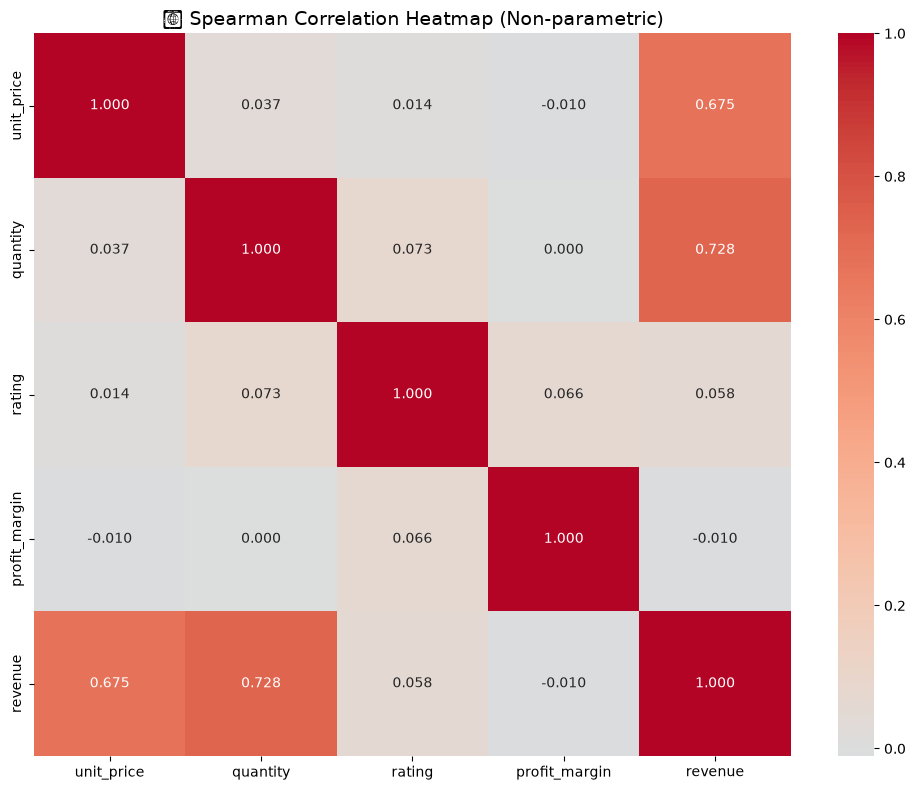


📈 DETAILED SPEARMAN CORRELATION TESTS:

⭐ RATING vs REVENUE:
  Spearman Correlation: 0.0582
  P-Value: 0.0000
  ✅ Significant (p < 0.05)
  Strength: Weak

💰 UNIT PRICE vs RATING:
  Spearman Correlation: 0.0143
  P-Value: 0.1533
  ❌ Not Significant

💰 UNIT PRICE vs REVENUE:
  Spearman Correlation: 0.6752
  P-Value: 0.0000
  ✅ Significant (p < 0.05)

📦 QUANTITY vs REVENUE:
  Spearman Correlation: 0.7284
  P-Value: 0.0000
  ✅ Significant (p < 0.05)

📈 PROFIT MARGIN vs REVENUE:
  Spearman Correlation: -0.0097
  P-Value: 0.3319
  ❌ Not Significant

💰 UNIT PRICE vs QUANTITY:
  Spearman Correlation: 0.0366
  P-Value: 0.0002
  ✅ Significant (p < 0.05)


In [8]:
print("\n" + "=" * 70)
print("📊 4. SPEARMAN CORRELATION (Non-parametric)")
print("=" * 70)

numerical_cols = ['unit_price', 'quantity', 'rating', 'profit_margin', 'revenue']

# Spearman Correlation Matrix
spearman_corr_matrix = df[numerical_cols].corr(method='spearman')

print("\n🔢 SPEARMAN CORRELATION MATRIX:")
print(spearman_corr_matrix.round(4))

# Visual correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('📊 Spearman Correlation Heatmap (Non-parametric)', fontsize=14)
plt.tight_layout()
plt.show()

# Detailed correlation tests
print("\n📈 DETAILED SPEARMAN CORRELATION TESTS:")

# 4.1 Rating vs Revenue
spearman_corr, p_value = spearmanr(df['rating'], df['revenue'])
print(f"\n⭐ RATING vs REVENUE:")
print(f"  Spearman Correlation: {spearman_corr:.4f}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")
if abs(spearman_corr) > 0.7:
    strength = "Strong"
elif abs(spearman_corr) > 0.5:
    strength = "Moderate"
else:
    strength = "Weak"
print(f"  Strength: {strength}")

# 4.2 Unit Price vs Rating
spearman_corr, p_value = spearmanr(df['unit_price'], df['rating'])
print(f"\n💰 UNIT PRICE vs RATING:")
print(f"  Spearman Correlation: {spearman_corr:.4f}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 4.3 Unit Price vs Revenue
spearman_corr, p_value = spearmanr(df['unit_price'], df['revenue'])
print(f"\n💰 UNIT PRICE vs REVENUE:")
print(f"  Spearman Correlation: {spearman_corr:.4f}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 4.4 Quantity vs Revenue
spearman_corr, p_value = spearmanr(df['quantity'], df['revenue'])
print(f"\n📦 QUANTITY vs REVENUE:")
print(f"  Spearman Correlation: {spearman_corr:.4f}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 4.5 Profit Margin vs Revenue
spearman_corr, p_value = spearmanr(df['profit_margin'], df['revenue'])
print(f"\n📈 PROFIT MARGIN vs REVENUE:")
print(f"  Spearman Correlation: {spearman_corr:.4f}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

# 4.6 Unit Price vs Quantity
spearman_corr, p_value = spearmanr(df['unit_price'], df['quantity'])
print(f"\n💰 UNIT PRICE vs QUANTITY:")
print(f"  Spearman Correlation: {spearman_corr:.4f}")
print(f"  P-Value: {p_value:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not Significant'}")

SUMMARY OF STATISTICAL TEST

In [9]:
print("\n" + "=" * 70)
print("📊 6. STATISTICAL TESTING SUMMARY")
print("=" * 70)

print("\n✅ KEY FINDINGS (Non-parametric Tests):")

# Revenue stats
print(f"\n💰 REVENUE STATISTICS:")
print(f"  Total: ${df['revenue'].sum():,.2f}")
print(f"  Mean: ${df['revenue'].mean():,.2f}")
print(f"  Median: ${df['revenue'].median():,.2f}")
print(f"  Std Dev: ${df['revenue'].std():,.2f}")
print(f"  Min: ${df['revenue'].min():,.2f}")
print(f"  Max: ${df['revenue'].max():,.2f}")

# Top performers
top_category = df.groupby('category')['revenue'].sum().idxmax()
top_category_revenue = df.groupby('category')['revenue'].sum().max()
top_branch = df.groupby('Branch')['revenue'].sum().idxmax()
top_branch_revenue = df.groupby('Branch')['revenue'].sum().max()
top_payment = df['payment_method'].value_counts().idxmax()
top_day = df['day_name'].value_counts().idxmax()

print(f"\n🏆 TOP PERFORMERS:")
print(f"  Best Category: {top_category} (${top_category_revenue:,.2f})")
print(f"  Best Branch: {top_branch} (${top_branch_revenue:,.2f})")
print(f"  Most Used Payment: {top_payment}")
print(f"  Busiest Day: {top_day}")

# Ratings
best_rated = df.groupby('category')['rating'].median().idxmax()
worst_rated = df.groupby('category')['rating'].median().idxmin()

print(f"\n⭐ RATING INSIGHTS:")
print(f"  Average Rating: {df['rating'].mean():.2f}/10")
print(f"  Median Rating: {df['rating'].median():.2f}/10")
print(f"  Best Rated Category: {best_rated} ({df[df['category']==best_rated]['rating'].median():.2f}/10)")
print(f"  Worst Rated Category: {worst_rated} ({df[df['category']==worst_rated]['rating'].median():.2f}/10)")

# Correlations
rating_revenue_corr, _ = spearmanr(df['rating'], df['revenue'])
price_rating_corr, _ = spearmanr(df['unit_price'], df['rating'])
price_revenue_corr, _ = spearmanr(df['unit_price'], df['revenue'])

print(f"\n📈 SPEARMAN CORRELATIONS:")
print(f"  Rating vs Revenue: {rating_revenue_corr:.3f} ({'Significant' if abs(rating_revenue_corr) > 0.1 else 'Weak'})")
print(f"  Price vs Rating: {price_rating_corr:.3f} ({'Significant' if abs(price_rating_corr) > 0.1 else 'Weak'})")
print(f"  Price vs Revenue: {price_revenue_corr:.3f} ({'Significant' if abs(price_revenue_corr) > 0.1 else 'Weak'})")

# Interpretations
print(f"\n💡 INTERPRETATIONS:")
if rating_revenue_corr > 0.3:
    print(f"  ✅ Higher ratings are associated with higher revenue")
elif rating_revenue_corr < -0.3:
    print(f"  ⚠️ Higher ratings are associated with lower revenue")
else:
    print(f"  ℹ️ No strong correlation between rating and revenue")

if price_rating_corr > 0.2:
    print(f"  ✅ Customers rate higher-priced items better")
elif price_rating_corr < -0.2:
    print(f"  ⚠️ Customers rate lower-priced items better")
else:
    print(f"  ℹ️ No strong correlation between price and rating")

print("\n" + "=" * 70)
print("✅ Statistical Testing Complete!")
print("📌 All tests use non-parametric methods (Mann-Whitney U, Kruskal-Wallis, Spearman)")
print("=" * 70)


📊 6. STATISTICAL TESTING SUMMARY

✅ KEY FINDINGS (Non-parametric Tests):

💰 REVENUE STATISTICS:
  Total: $1,155,753.96
  Mean: $115.58
  Median: $88.00
  Std Dev: $89.60
  Min: $10.17
  Max: $599.76

🏆 TOP PERFORMERS:
  Best Category: Fashion accessories ($481,584.55)
  Best Branch: WALM009 ($25,271.22)
  Most Used Payment: Credit card
  Busiest Day: Tuesday

⭐ RATING INSIGHTS:
  Average Rating: 5.83/10
  Median Rating: 6.00/10
  Best Rated Category: Food and beverages (7.30/10)
  Worst Rated Category: Electronic accessories (6.00/10)

📈 SPEARMAN CORRELATIONS:
  Rating vs Revenue: 0.058 (Weak)
  Price vs Rating: 0.014 (Weak)
  Price vs Revenue: 0.675 (Significant)

💡 INTERPRETATIONS:
  ℹ️ No strong correlation between rating and revenue
  ℹ️ No strong correlation between price and rating

✅ Statistical Testing Complete!
📌 All tests use non-parametric methods (Mann-Whitney U, Kruskal-Wallis, Spearman)


DASHBOARD_STATISTICALSUMARY

📊 RUNNING STATISTICAL TESTS...
✅ Loaded dataset: 10,000 rows, 19 columns
💰 Total Revenue: $1,155,753.96
✅ All tests completed successfully!


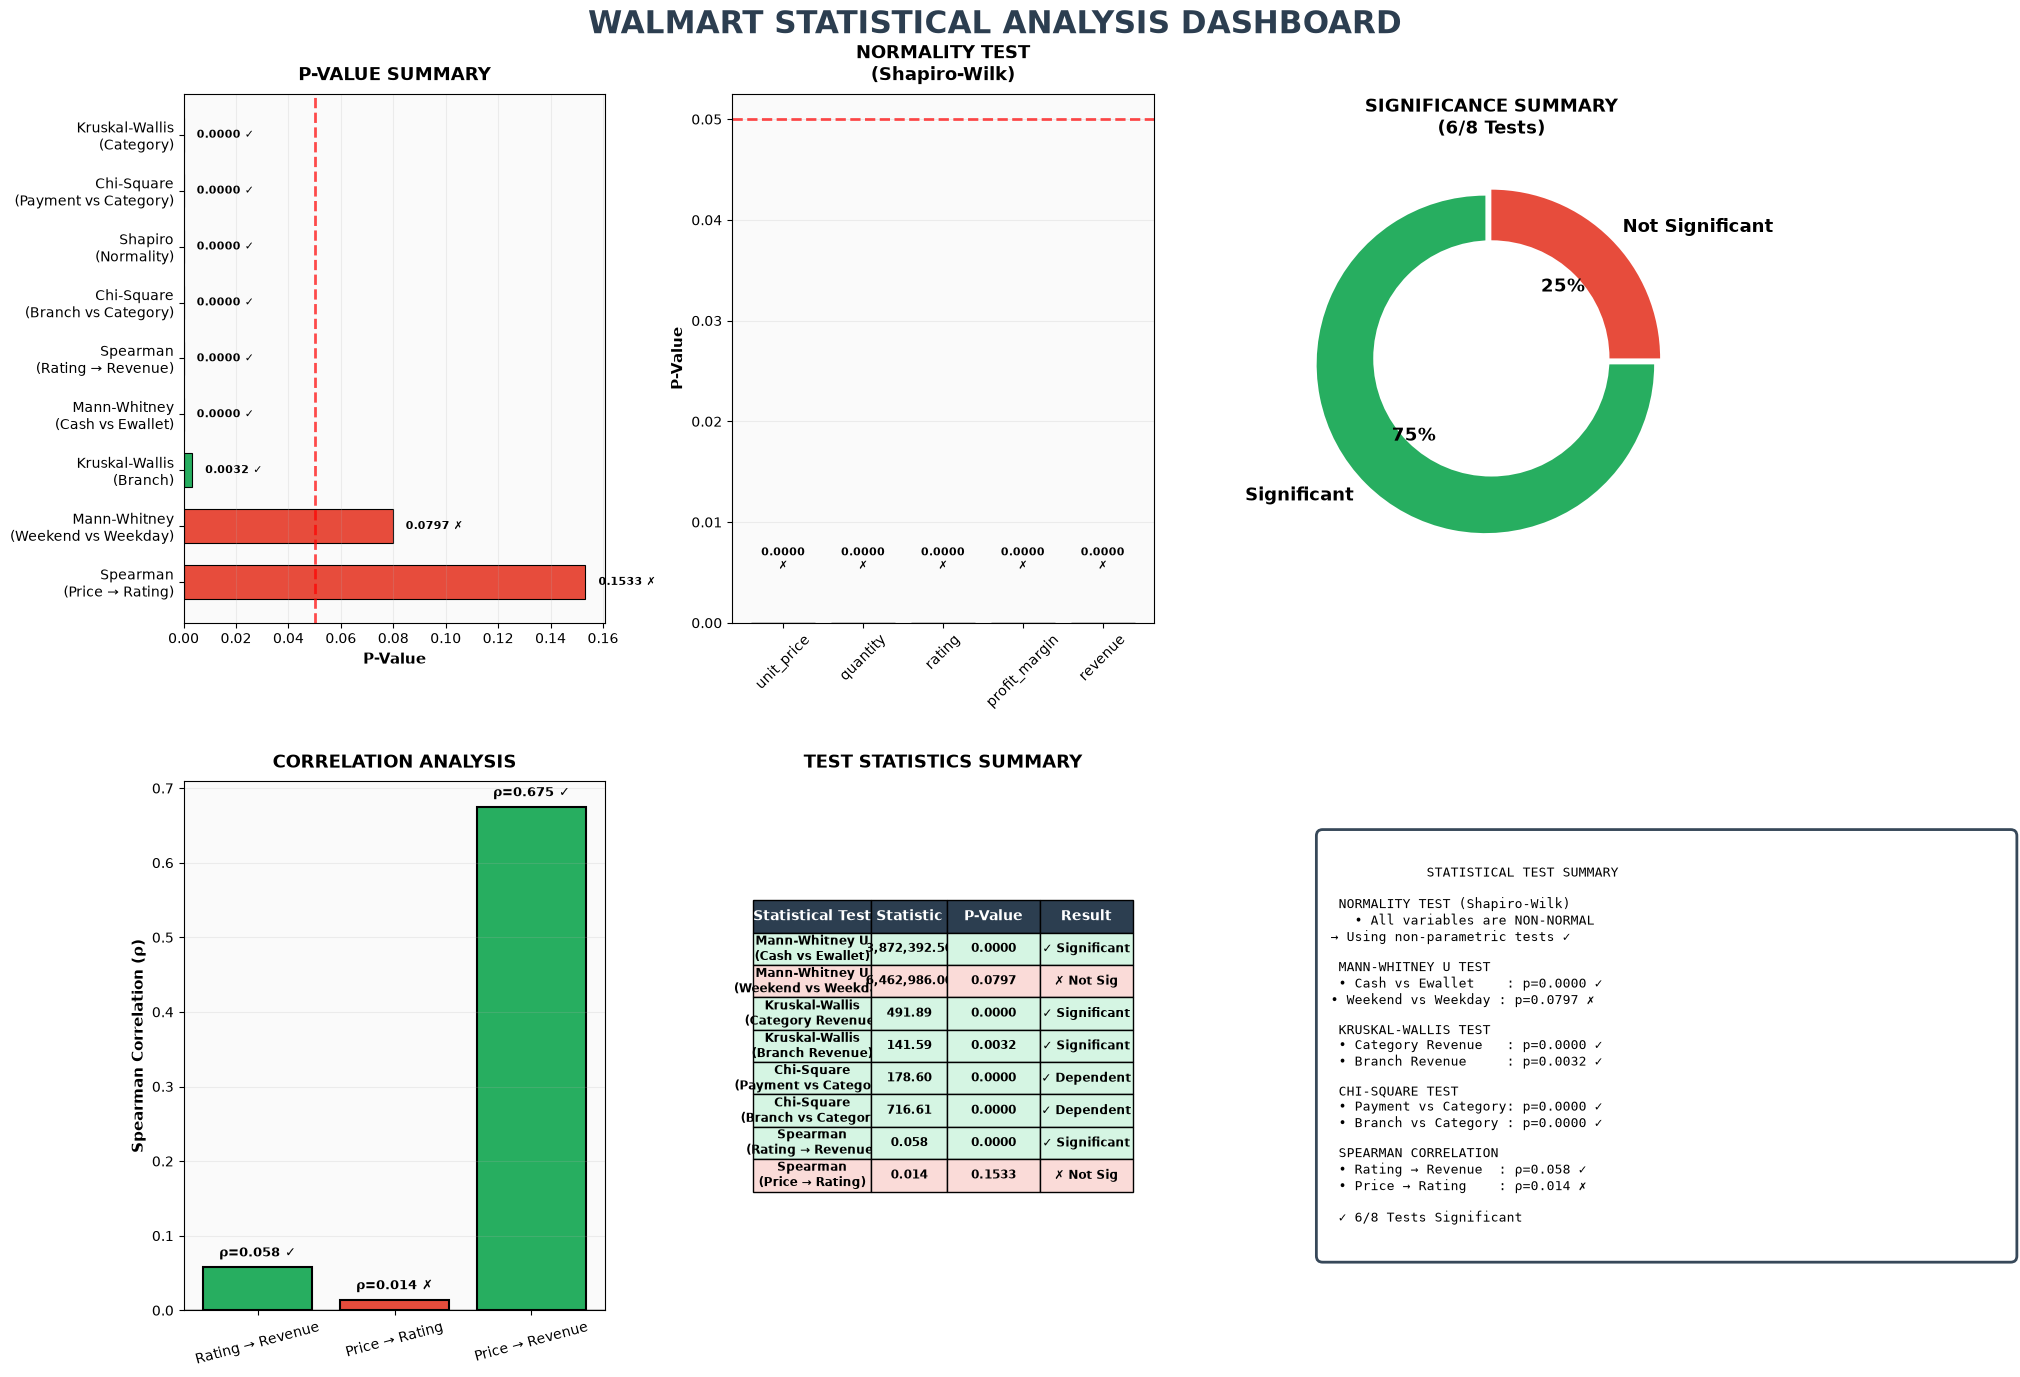


📊 DETAILED STATISTICAL TEST RESULTS

📊 TOTAL TESTS PERFORMED: 8
✅ SIGNIFICANT TESTS: 6
❌ NON-SIGNIFICANT TESTS: 2

1️⃣ NORMALITY TEST (Shapiro-Wilk):
----------------------------------------------------------------------------------------------------
  • unit_price     : ❌ Non-Normal (p = 0.0000)
  • quantity       : ❌ Non-Normal (p = 0.0000)
  • rating         : ❌ Non-Normal (p = 0.0000)
  • profit_margin  : ❌ Non-Normal (p = 0.0000)
  • revenue        : ❌ Non-Normal (p = 0.0000)

2️⃣ MANN-WHITNEY U TEST:
----------------------------------------------------------------------------------------------------
  • Cash vs Ewallet        : U = 3,872,392.50, p = 0.0000 ✅ Significant
  • Weekend vs Weekday     : U = 6,462,986.00, p = 0.0797 ❌ Not Significant

3️⃣ KRUSKAL-WALLIS TEST:
----------------------------------------------------------------------------------------------------
  • Category Revenue       : H = 491.89, p = 0.0000 ✅ Significant
  • Branch Revenue         : H = 141.59, p = 

In [12]:
# Professional Statistical Test Dashboard - CLEAN VERSION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, spearmanr, shapiro
import warnings
warnings.filterwarnings('ignore')

# Prepare your data - FIXED: Added file path to read_csv
df = pd.read_csv(r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart_Cleaned.csv', parse_dates=['date'])
df['revenue'] = df['unit_price'] * df['quantity']
df['is_weekend'] = df['weekday'].isin([6, 7]).astype(int)

print("=" * 80)
print("📊 RUNNING STATISTICAL TESTS...")
print("=" * 80)
print(f"✅ Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"💰 Total Revenue: ${df['revenue'].sum():,.2f}")
print("=" * 80)

# ============================================================================
# RUN ALL STATISTICAL TESTS
# ============================================================================

# 1. Normality Test (Shapiro-Wilk)
normality_results = {}
for col in ['unit_price', 'quantity', 'rating', 'profit_margin', 'revenue']:
    sample = df[col].sample(min(5000, len(df)), random_state=42)
    stat, p_val = shapiro(sample)
    normality_results[col] = {'statistic': stat, 'p_value': p_val, 'normal': p_val > 0.05}

# 2. Mann-Whitney U Test
cash_rev = df[df['payment_method'] == 'Cash']['revenue']
ewallet_rev = df[df['payment_method'] == 'Ewallet']['revenue']
weekend_rev = df[df['is_weekend'] == 1]['revenue']
weekday_rev = df[df['is_weekend'] == 0]['revenue']

u_stat1, p_val1 = mannwhitneyu(cash_rev, ewallet_rev, alternative='two-sided')
u_stat2, p_val2 = mannwhitneyu(weekend_rev, weekday_rev, alternative='two-sided')

# 3. Kruskal-Wallis Test
categories = df['category'].unique()
branches = df['Branch'].unique()
h_stat_cat, p_val_cat = kruskal(*[df[df['category'] == cat]['revenue'] for cat in categories])
h_stat_branch, p_val_branch = kruskal(*[df[df['Branch'] == branch]['revenue'] for branch in branches])

# 4. Chi-Square Test
contingency1 = pd.crosstab(df['payment_method'], df['category'])
contingency2 = pd.crosstab(df['Branch'], df['category'])
chi2_1, p_val_chi1 = chi2_contingency(contingency1)[:2]
chi2_2, p_val_chi2 = chi2_contingency(contingency2)[:2]

# 5. Spearman Correlation
spearman_rating_rev, p_val_spear1 = spearmanr(df['rating'], df['revenue'])
spearman_price_rating, p_val_spear2 = spearmanr(df['unit_price'], df['rating'])
spearman_price_rev, p_val_spear3 = spearmanr(df['unit_price'], df['revenue'])

# Calculate summary stats
summary_data = {
    'Test': ['Mann-Whitney\n(Cash vs Ewallet)', 'Mann-Whitney\n(Weekend vs Weekday)',
             'Kruskal-Wallis\n(Category)', 'Kruskal-Wallis\n(Branch)',
             'Chi-Square\n(Payment vs Category)', 'Chi-Square\n(Branch vs Category)',
             'Spearman\n(Rating → Revenue)', 'Spearman\n(Price → Rating)'],
    'P-Value': [p_val1, p_val2, p_val_cat, p_val_branch, p_val_chi1, p_val_chi2, p_val_spear1, p_val_spear2],
    'Significant': [p_val1 < 0.05, p_val2 < 0.05, p_val_cat < 0.05, p_val_branch < 0.05,
                    p_val_chi1 < 0.05, p_val_chi2 < 0.05, p_val_spear1 < 0.05, p_val_spear2 < 0.05]
}

summary_df = pd.DataFrame(summary_data)
significant_count = summary_df['Significant'].sum()
total_tests = len(summary_df)

print("✅ All tests completed successfully!")

# ============================================================================
# CREATE PROFESSIONAL DASHBOARD - CLEAN LAYOUT
# ============================================================================

# Create figure with proper spacing
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('white')

# Main title
fig.suptitle('WALMART STATISTICAL ANALYSIS DASHBOARD', 
             fontsize=22, fontweight='bold', y=0.98, color='#2c3e50')

# ============================================================================
# PANEL 1: P-Value Summary (Top Left)
# ============================================================================
ax1 = plt.subplot(2, 3, 1)

test_names_short = ['Shapiro\n(Normality)', 'Mann-Whitney\n(Cash vs Ewallet)', 
                    'Mann-Whitney\n(Weekend vs Weekday)', 'Kruskal-Wallis\n(Category)',
                    'Kruskal-Wallis\n(Branch)', 'Chi-Square\n(Payment vs Category)',
                    'Chi-Square\n(Branch vs Category)', 'Spearman\n(Rating → Revenue)',
                    'Spearman\n(Price → Rating)']

p_values_all = [
    max([normality_results[col]['p_value'] for col in normality_results]),
    p_val1, p_val2, p_val_cat, p_val_branch,
    p_val_chi1, p_val_chi2, p_val_spear1, p_val_spear2
]

p_df_all = pd.DataFrame({'Test': test_names_short, 'P-Value': p_values_all})
p_df_all = p_df_all.sort_values('P-Value', ascending=False)

colors_bar = ['#e74c3c' if p > 0.05 else '#27ae60' for p in p_df_all['P-Value']]

bars = ax1.barh(p_df_all['Test'], p_df_all['P-Value'], color=colors_bar, 
                edgecolor='black', linewidth=0.8, height=0.6)
ax1.axvline(x=0.05, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('P-Value', fontsize=11, fontweight='bold')
ax1.set_title('P-VALUE SUMMARY', fontsize=13, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.2, axis='x')
ax1.set_facecolor('#fafafa')

for i, (bar, p_val) in enumerate(zip(bars, p_df_all['P-Value'])):
    status = '✓' if p_val < 0.05 else '✗'
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{p_val:.4f} {status}', va='center', fontsize=8, fontweight='bold')

# ============================================================================
# PANEL 2: Normality Test Results (Top Center)
# ============================================================================
ax2 = plt.subplot(2, 3, 2)

norm_cols = list(normality_results.keys())
norm_p_vals = [normality_results[col]['p_value'] for col in norm_cols]
norm_colors = ['#27ae60' if p > 0.05 else '#e74c3c' for p in norm_p_vals]

bars2 = ax2.bar(norm_cols, norm_p_vals, color=norm_colors, edgecolor='black', linewidth=1)
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_ylabel('P-Value', fontsize=11, fontweight='bold')
ax2.set_title('NORMALITY TEST\n(Shapiro-Wilk)', fontsize=13, fontweight='bold', pad=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.2, axis='y')
ax2.set_facecolor('#fafafa')

for bar, p_val in zip(bars2, norm_p_vals):
    height = bar.get_height()
    status = '✓' if p_val > 0.05 else '✗'
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{p_val:.4f}\n{status}', ha='center', va='bottom', 
             fontsize=8, fontweight='bold')

# ============================================================================
# PANEL 3: Significance Summary (Top Right)
# ============================================================================
ax3 = plt.subplot(2, 3, 3)

colors_donut = ['#27ae60', '#e74c3c']
wedges, texts, autotexts = ax3.pie([significant_count, total_tests - significant_count], 
                                   labels=['Significant', 'Not Significant'],
                                   autopct='%1.0f%%', startangle=90,
                                   colors=colors_donut,
                                   explode=(0.05, 0),
                                   textprops={'fontsize': 13, 'fontweight': 'bold'})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax3.add_artist(centre_circle)
ax3.set_title(f'SIGNIFICANCE SUMMARY\n({significant_count}/{total_tests} Tests)', 
              fontsize=13, fontweight='bold', pad=10)

# ============================================================================
# PANEL 4: Correlation Analysis (Bottom Left)
# ============================================================================
ax4 = plt.subplot(2, 3, 4)

correlation_data = {
    'Relationship': ['Rating → Revenue', 'Price → Rating', 'Price → Revenue'],
    'Correlation': [spearman_rating_rev, spearman_price_rating, spearman_price_rev],
    'P-Value': [p_val_spear1, p_val_spear2, p_val_spear3],
    'Significant': [p_val_spear1 < 0.05, p_val_spear2 < 0.05, p_val_spear3 < 0.05]
}

corr_df = pd.DataFrame(correlation_data)

bars3 = ax4.bar(corr_df['Relationship'], corr_df['Correlation'], 
               color=['#27ae60' if sig else '#e74c3c' for sig in corr_df['Significant']],
               edgecolor='black', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_ylabel('Spearman Correlation (ρ)', fontsize=11, fontweight='bold')
ax4.set_title('CORRELATION ANALYSIS', fontsize=13, fontweight='bold', pad=10)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(True, alpha=0.2, axis='y')
ax4.set_facecolor('#fafafa')

for bar, row in zip(bars3, corr_df.iterrows()):
    height = bar.get_height()
    status = '✓' if row[1]['Significant'] else '✗'
    y_pos = height + 0.01 if height >= 0 else height - 0.03
    va = 'bottom' if height >= 0 else 'top'
    ax4.text(bar.get_x() + bar.get_width()/2., y_pos,
             f'ρ={height:.3f} {status}', ha='center', va=va, 
             fontsize=9, fontweight='bold')

# ============================================================================
# PANEL 5: Test Statistics Table (Bottom Center)
# ============================================================================
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')

# Create table data with multi-line text
table_data = [
    ['Statistical Test', 'Statistic', 'P-Value', 'Result'],
    ['Mann-Whitney U\n(Cash vs Ewallet)', f'{u_stat1:,.2f}', f'{p_val1:.4f}', '✓ Significant' if p_val1<0.05 else '✗ Not Sig'],
    ['Mann-Whitney U\n(Weekend vs Weekday)', f'{u_stat2:,.2f}', f'{p_val2:.4f}', '✓ Significant' if p_val2<0.05 else '✗ Not Sig'],
    ['Kruskal-Wallis\n(Category Revenue)', f'{h_stat_cat:.2f}', f'{p_val_cat:.4f}', '✓ Significant' if p_val_cat<0.05 else '✗ Not Sig'],
    ['Kruskal-Wallis\n(Branch Revenue)', f'{h_stat_branch:.2f}', f'{p_val_branch:.4f}', '✓ Significant' if p_val_branch<0.05 else '✗ Not Sig'],
    ['Chi-Square\n(Payment vs Category)', f'{chi2_1:.2f}', f'{p_val_chi1:.4f}', '✓ Dependent' if p_val_chi1<0.05 else '✗ Independent'],
    ['Chi-Square\n(Branch vs Category)', f'{chi2_2:.2f}', f'{p_val_chi2:.4f}', '✓ Dependent' if p_val_chi2<0.05 else '✗ Independent'],
    ['Spearman\n(Rating → Revenue)', f'{spearman_rating_rev:.3f}', f'{p_val_spear1:.4f}', '✓ Significant' if p_val_spear1<0.05 else '✗ Not Sig'],
    ['Spearman\n(Price → Rating)', f'{spearman_price_rating:.3f}', f'{p_val_spear2:.4f}', '✓ Significant' if p_val_spear2<0.05 else '✗ Not Sig']
]

# Create table
table = ax5.table(cellText=table_data, loc='center', cellLoc='center',
                  colWidths=[0.28, 0.18, 0.22, 0.22])

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.8)

# Style header
for j in range(4):
    table[(0, j)].set_facecolor('#2c3e50')
    table[(0, j)].set_text_props(weight='bold', color='white', fontsize=10)

# Style rows
for i in range(1, len(table_data)):
    result = table_data[i][3]
    if '✓' in result:
        for j in range(4):
            table[(i, j)].set_facecolor('#d5f5e3')
            table[(i, j)].set_text_props(weight='bold')
    else:
        for j in range(4):
            table[(i, j)].set_facecolor('#fadbd8')
            table[(i, j)].set_text_props(weight='bold')

ax5.set_title('TEST STATISTICS SUMMARY', fontsize=13, fontweight='bold', pad=10)

# ============================================================================
# PANEL 6: Overall Summary (Bottom Right)
# ============================================================================
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_text = f"""

             STATISTICAL TEST SUMMARY                 

  NORMALITY TEST (Shapiro-Wilk)                                                     
    • All variables are NON-NORMAL                                                    
 → Using non-parametric tests ✓                                                    
                                                                                    
  MANN-WHITNEY U TEST                                                               
  • Cash vs Ewallet    : p={p_val1:.4f} {'✓' if p_val1<0.05 else '✗'}              
 • Weekend vs Weekday : p={p_val2:.4f} {'✓' if p_val2<0.05 else '✗'}              
                                                                                    
  KRUSKAL-WALLIS TEST                                                               
  • Category Revenue   : p={p_val_cat:.4f} {'✓' if p_val_cat<0.05 else '✗'}        
  • Branch Revenue     : p={p_val_branch:.4f} {'✓' if p_val_branch<0.05 else '✗'}  
                                                          
  CHI-SQUARE TEST                                        
  • Payment vs Category: p={p_val_chi1:.4f} {'✓' if p_val_chi1<0.05 else '✗'}   
  • Branch vs Category : p={p_val_chi2:.4f} {'✓' if p_val_chi2<0.05 else '✗'}   
                                                          
  SPEARMAN CORRELATION                                   
  • Rating → Revenue  : ρ={spearman_rating_rev:.3f} {'✓' if p_val_spear1<0.05 else '✗'} 
  • Price → Rating    : ρ={spearman_price_rating:.3f} {'✓' if p_val_spear2<0.05 else '✗'} 
                                                          
  ✓ {significant_count}/{total_tests} Tests Significant  

"""

ax6.text(0.1, 0.5, summary_text, fontsize=9, verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.95, 
                   edgecolor='#2c3e50', linewidth=2))

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
plt.show()

# ============================================================================
# PRINT DETAILED RESULTS
# ============================================================================
print("\n" + "=" * 100)
print("📊 DETAILED STATISTICAL TEST RESULTS")
print("=" * 100)

print(f"\n📊 TOTAL TESTS PERFORMED: {total_tests}")
print(f"✅ SIGNIFICANT TESTS: {significant_count}")
print(f"❌ NON-SIGNIFICANT TESTS: {total_tests - significant_count}")

print("\n" + "=" * 100)
print("1️⃣ NORMALITY TEST (Shapiro-Wilk):")
print("-" * 100)
for col in normality_results:
    p_val = normality_results[col]['p_value']
    status = '✅ Normal' if p_val > 0.05 else '❌ Non-Normal'
    print(f"  • {col:15s}: {status:12s} (p = {p_val:.4f})")

print("\n" + "=" * 100)
print("2️⃣ MANN-WHITNEY U TEST:")
print("-" * 100)
print(f"  • Cash vs Ewallet        : U = {u_stat1:,.2f}, p = {p_val1:.4f} {'✅ Significant' if p_val1<0.05 else '❌ Not Significant'}")
print(f"  • Weekend vs Weekday     : U = {u_stat2:,.2f}, p = {p_val2:.4f} {'✅ Significant' if p_val2<0.05 else '❌ Not Significant'}")

print("\n" + "=" * 100)
print("3️⃣ KRUSKAL-WALLIS TEST:")
print("-" * 100)
print(f"  • Category Revenue       : H = {h_stat_cat:.2f}, p = {p_val_cat:.4f} {'✅ Significant' if p_val_cat<0.05 else '❌ Not Significant'}")
print(f"  • Branch Revenue         : H = {h_stat_branch:.2f}, p = {p_val_branch:.4f} {'✅ Significant' if p_val_branch<0.05 else '❌ Not Significant'}")

print("\n" + "=" * 100)
print("4️⃣ CHI-SQUARE TEST:")
print("-" * 100)
print(f"  • Payment vs Category    : χ² = {chi2_1:.2f}, p = {p_val_chi1:.4f} {'✅ Dependent' if p_val_chi1<0.05 else '❌ Independent'}")
print(f"  • Branch vs Category     : χ² = {chi2_2:.2f}, p = {p_val_chi2:.4f} {'✅ Dependent' if p_val_chi2<0.05 else '❌ Independent'}")

print("\n" + "=" * 100)
print("5️⃣ SPEARMAN CORRELATION:")
print("-" * 100)
print(f"  • Rating → Revenue       : ρ = {spearman_rating_rev:.4f}, p = {p_val_spear1:.4f} {'✅ Significant' if p_val_spear1<0.05 else '❌ Not Significant'}")
print(f"  • Price → Rating         : ρ = {spearman_price_rating:.4f}, p = {p_val_spear2:.4f} {'✅ Significant' if p_val_spear2<0.05 else '❌ Not Significant'}")
print(f"  • Price → Revenue        : ρ = {spearman_price_rev:.4f}, p = {p_val_spear3:.4f} {'✅ Significant' if p_val_spear3<0.05 else '❌ Not Significant'}")

print("\n" + "=" * 100)
print(f"📊 SUMMARY: {significant_count}/{total_tests} Tests are Statistically Significant")
print("=" * 100)